# Multi-Method VaR Backtesting Model
## SPY (S&P 500 ETF) | 2018–2026 | 99% Confidence

This project implements and backtests four Value-at-Risk models on SPY daily returns,
comparing their performance across calm and stressed market regimes including the 
COVID-19 crash (2020) and the 2022 rate hike drawdown.


In [1]:
!pip install arch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
import datetime as dt
import seaborn as sb
import arch as ac
from scipy.stats import t as student_t
from scipy.stats import chi2
import matplotlib.dates as mdates

## 1. Data
Daily adjusted closing prices for SPY downloaded via yfinance (2018–present).
Log returns computed as: r_t = ln(P_t / P_{t-1})
Rolling window: 252 trading days | Backtesting period: 2020–2026


In [3]:
startdate= dt.datetime(2018, 1, 1)
enddate= dt.datetime.now()

In [4]:
Tickers= ['SPY']

In [5]:
df= yf.download(Tickers, startdate, enddate, auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [6]:
adj_closing_price= df['Close']

In [7]:
log_returns= np.log(adj_closing_price/adj_closing_price.shift(1))
log_returns= log_returns.dropna()
print(log_returns)

Ticker           SPY
Date                
2018-01-03  0.006305
2018-01-04  0.004206
2018-01-05  0.006642
2018-01-08  0.001827
2018-01-09  0.002261
...              ...
2026-06-01  0.002719
2026-06-02  0.001357
2026-06-03 -0.007042
2026-06-04  0.003772
2026-06-05 -0.026148

[2117 rows x 1 columns]


In [8]:
log_returns= log_returns["SPY"]

In [9]:
print(type(log_returns))
print(log_returns.shape)

<class 'pandas.core.series.Series'>
(2117,)


## 2. VaR Models
Four methods implemented at 99% confidence level:
- **Historical Simulation** — empirical percentile of rolling returns
- **Parametric (Variance-Covariance)** — assumes normally distributed returns
- **Monte Carlo GBM** — simulates 10,000 paths using Geometric Brownian Motion
- **Monte Carlo Student-t** — GBM with fat-tailed Student-t residuals (df=5)

In [10]:
window= 252 
confidence= 0.99

hist_var = []
hist_es= []
hist_dates= []

In [11]:
for i in range(window, len(log_returns)):
    rolling_window = log_returns.iloc[i - window:i]
    var= np.percentile(rolling_window, 100 - (confidence*100))
    tail= rolling_window[rolling_window<= var]
    
    if len(tail) >0:
        hist_var.append(abs(var))
        hist_es.append(abs(tail.mean()))
        hist_dates.append(log_returns.index[i])
        
    
    

In [12]:
hist_var= pd.Series(hist_var, index= hist_dates)
hist_es = pd.Series(hist_es, index= hist_dates)

In [13]:
print(hist_var.describe())
print(hist_es.describe())

count    1865.000000
mean        0.033682
std         0.015644
min         0.014625
25%         0.022004
50%         0.030269
75%         0.037387
max         0.070126
dtype: float64
count    1865.000000
mean        0.042685
std         0.024442
min         0.015973
25%         0.026158
50%         0.034448
75%         0.051890
max         0.099256
dtype: float64


In [14]:
param_var= []
param_es= []
param_dates= []

In [15]:
for i in range(window, len(log_returns)):
    rolling_window= log_returns.iloc[i - window:i]
    mu= rolling_window.mean()
    sigma= rolling_window.std()
    var= norm.ppf(0.01, mu, sigma)
    es= mu - sigma*norm.pdf(norm.ppf(0.01))/0.01
    param_var.append(abs(var))
    param_es.append(abs(es))
    param_dates.append(log_returns.index[i])

    
    

In [16]:
param_var= pd.Series(param_var, index= param_dates)
param_es = pd.Series(param_es, index= param_dates)

In [17]:
print(param_var.describe())
print(param_es.describe())

count    1865.000000
mean        0.026874
std         0.009754
min         0.015218
25%         0.018780
50%         0.024265
75%         0.030373
max         0.049113
dtype: float64
count    1865.000000
mean        0.030867
std         0.011143
min         0.017579
25%         0.021658
50%         0.027856
75%         0.034776
max         0.056348
dtype: float64


In [18]:
np.random.seed(42)
n_simulations= 10000
dt= 1/252
mc_var= []
mc_es= []
mc_dates= []
for i in range(window, len(log_returns)):
    rolling_window= log_returns.iloc[i - window:i]
    mu= rolling_window.mean()*252
    sigma= rolling_window.std()*np.sqrt(252)
    Z= np.random.normal(0, 1, n_simulations)
    simulated = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    var= np.percentile(simulated, 100 - (confidence*100))
    tail= simulated[simulated<= var]
    mc_var.append(abs(var))
    mc_es.append(abs(tail.mean()))
    mc_dates.append(log_returns.index[i])
        
    

In [19]:
mc_var= pd.Series(mc_var, index= mc_dates)
mc_es = pd.Series(mc_es, index= mc_dates)

In [20]:
print(mc_var.describe())
print(mc_es.describe())

count    1865.000000
mean        0.026931
std         0.009816
min         0.014762
25%         0.018869
50%         0.024493
75%         0.030372
max         0.050538
dtype: float64
count    1865.000000
mean        0.030928
std         0.011193
min         0.016935
25%         0.021649
50%         0.028171
75%         0.035046
max         0.057920
dtype: float64


In [21]:
np.random.seed(42)
n_simulations= 10000
dt= 1/252
df_t= 5
mc_t_var= []
mc_t_es= []
mc_t_dates= []
for i in range(window, len(log_returns)):
    rolling_window= log_returns.iloc[i - window:i]
    mu= rolling_window.mean()*252
    sigma= rolling_window.std()*np.sqrt(252)
    Z= student_t.rvs(df=df_t, size= n_simulations)
    simulated = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    var= np.percentile(simulated, 100 - (confidence*100))
    tail= simulated[simulated<= var]
    mc_t_var.append(abs(var))
    mc_t_es.append(abs(tail.mean()))
    mc_t_dates.append(log_returns.index[i])
        

In [22]:
mc_t_var= pd.Series(mc_t_var, index= mc_t_dates)
mc_t_es = pd.Series(mc_t_es, index= mc_t_dates)

In [23]:
print(mc_t_var.describe())
print(mc_t_es.describe())

count    1865.000000
mean        0.039135
std         0.014069
min         0.021300
25%         0.027675
50%         0.035716
75%         0.044005
max         0.075537
dtype: float64
count    1865.000000
mean        0.051935
std         0.018655
min         0.028253
25%         0.036842
50%         0.047740
75%         0.059102
max         0.102937
dtype: float64


## 3. Backtesting
Two formal statistical tests applied to each model:
- **Kupiec POF Test** — tests whether breach frequency matches expected 1%
- **Christoffersen Test** — tests whether breaches are independently distributed
Critical value: χ²(1) = 3.841 at 5% significance


In [24]:
actual_returns = log_returns.iloc[window:].values
hits_hist = (actual_returns < -hist_var.values).astype(int)
hits_param = (actual_returns < -param_var.values).astype(int)
hits_mc = (actual_returns < -mc_var.values).astype(int)
hits_mc_t = (actual_returns < -mc_t_var.values).astype(int)
expected= len(hits_hist)*0.01




In [25]:
print(expected, hits_hist.sum(), hits_param.sum(),hits_mc.sum(), hits_mc_t.sum())

18.650000000000002 32 50 50 19


In [26]:
def kupiec_test(hits, n ,confidence=0.99):
    p= 1 - confidence
    x= hits.sum()
    p_hat= x/n
    if p_hat == 0 or p_hat ==1:
        return None, None
    lr= -2* np.log((p**x *(1-p)**(n-x))/(p_hat**x*(1-p_hat)**(n-x)))
    p_value = 1- chi2.cdf(lr, df=1)
    return round(lr,4), round(p_value, 4)
n= len(hits_hist)
lr_hist, pv_hist = kupiec_test(hits_hist, n)
lr_param, pv_param = kupiec_test(hits_param, n)
lr_mc, pv_mc = kupiec_test(hits_mc, n)
lr_mc_t, pv_mc_t = kupiec_test(hits_mc_t, n)
print(lr_hist, pv_hist,lr_param, pv_param,lr_mc, pv_mc,lr_mc_t, pv_mc_t)
                
    

7.9497 0.0048 36.453 0.0 36.453 0.0 0.0066 0.9353


In [27]:
def christoffersen_test(hits):
    n= len(hits)
    n00= sum((hits[i]==0 and hits[i+1]==0) for i in range (n-1))
    n01= sum((hits[i]==0 and hits[i+1]==1) for i in range (n-1))
    n10= sum((hits[i]==1 and hits[i+1]==0) for i in range (n-1))
    n11= sum((hits[i]==1 and hits[i+1]==1) for i in range (n-1))
    if n11==0:
        lr_ind= 0.0
        p_value= 1.0
        return round(lr_ind, 4), round(p_value,4)
    pi01= n01/ (n00+n01)
    pi11= n11/ (n10+ n11)
    pi= (n01+n11)/(n00+n01+n10+n11)
    
    if pi01==0 or pi11==0 or pi==0:
        return None, None
    
    lr_ind= -2*np.log((pi**(n01+n11)*(1-pi)**(n00+n10))/(pi01**n01*(1-pi01)**n00*pi11**n11*(1-pi11)**n10))
    p_value= 1-chi2.cdf(lr_ind, df=1)
    return round(lr_ind,4), round(p_value, 4)
lr_c_hist, pv_c_hist = christoffersen_test(hits_hist)    
lr_c_param, pv_c_param = christoffersen_test(hits_param) 
lr_c_mc, pv_c_mc = christoffersen_test(hits_mc) 
lr_c_mc_t, pv_c_mc_t = christoffersen_test(hits_mc_t) 
print(lr_c_hist, pv_c_hist,lr_c_param, pv_c_param,lr_c_mc, pv_c_mc,lr_c_mc_t, pv_c_mc_t)


10.0151 0.0016 6.576 0.0103 6.576 0.0103 12.0521 0.0005


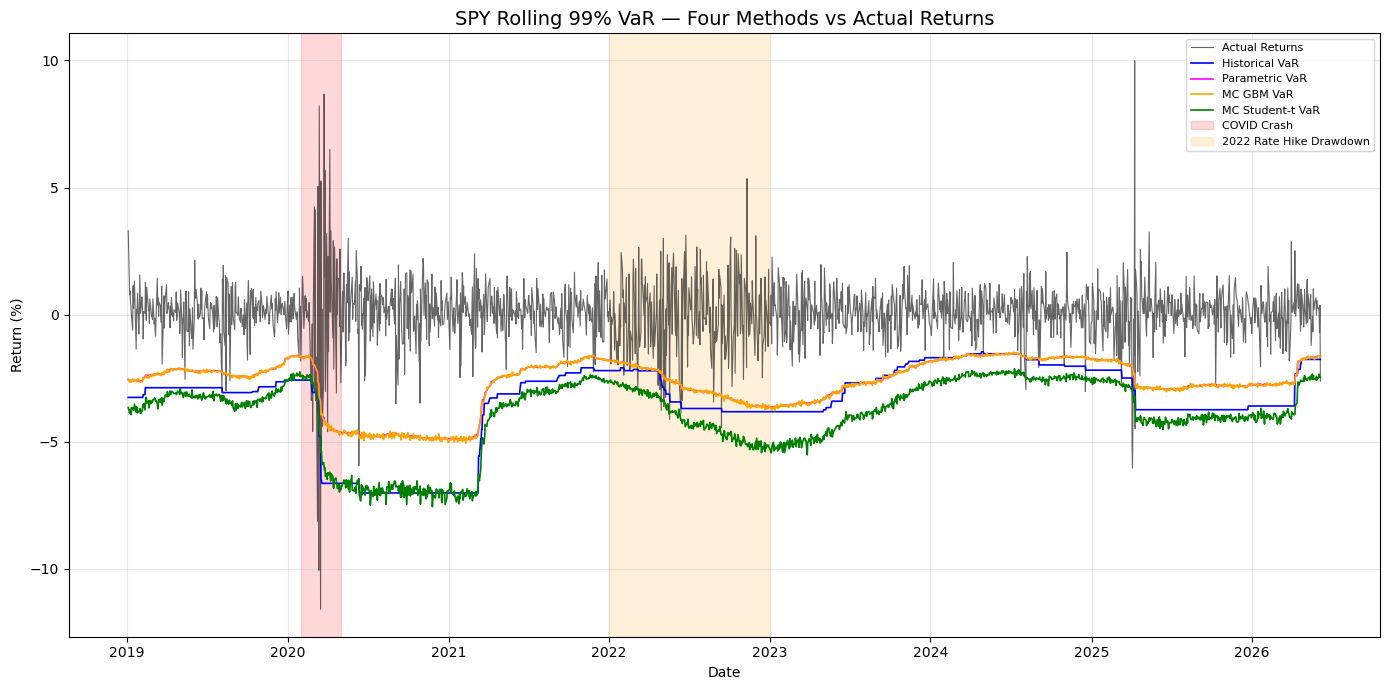

In [28]:
fig, ax = plt.subplots(figsize=(14,7))
ax.plot(log_returns.iloc[window:].index, log_returns.iloc[window:].values*100, color= 'black', linewidth= 0.8,alpha=0.6, label='Actual Returns')
ax.plot(hist_var.index,-hist_var.values*100, color= 'blue', linewidth=1.2, label='Historical VaR')
ax.plot(param_var.index,-param_var.values*100, color= 'magenta', linewidth=1.2, label='Parametric VaR')
ax.plot(mc_var.index,-mc_var.values*100, color= 'orange', linewidth=1.2, label='MC GBM VaR')
ax.plot(mc_t_var.index,-mc_t_var.values*100, color= 'green', linewidth=1.2, label='MC Student-t VaR')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
           alpha=0.15, color='red', label='COVID Crash')


ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.15, color='orange', label='2022 Rate Hike Drawdown')

ax.set_title('SPY Rolling 99% VaR — Four Methods vs Actual Returns', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Return (%)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('var_comparison.png', dpi=150)
plt.show()



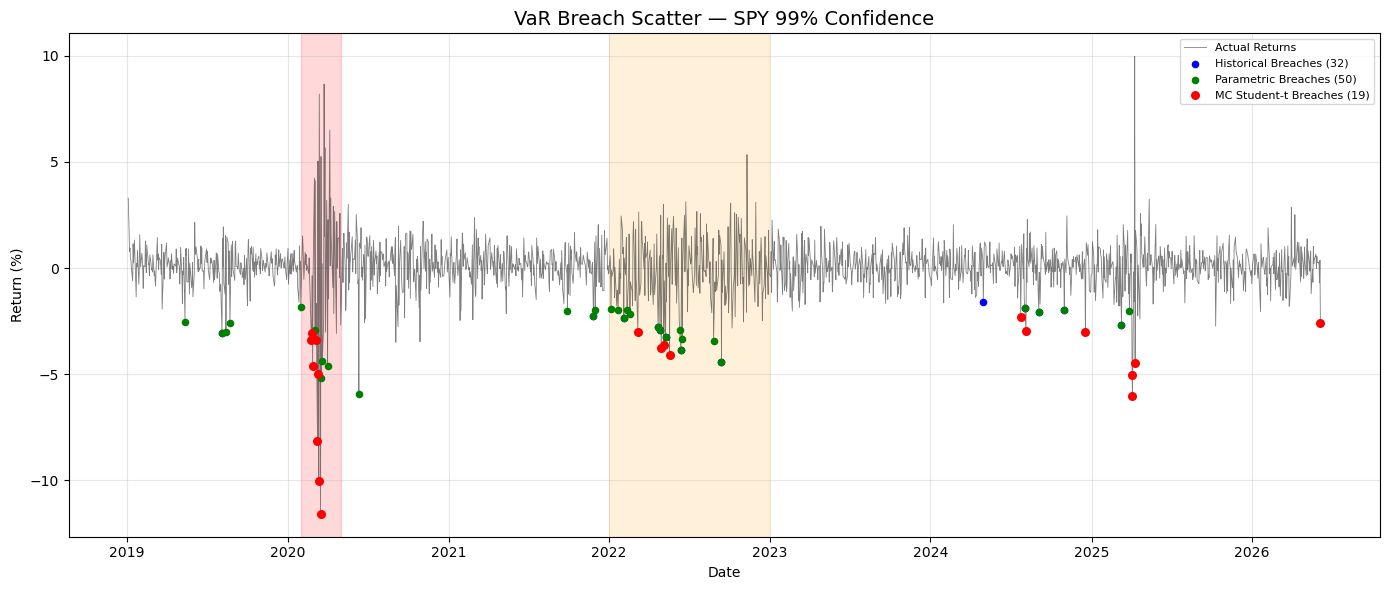

In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

actual = log_returns.iloc[window:] * 100
dates = actual.index


ax.plot(dates, actual.values, color='black', linewidth=0.6, alpha=0.5, label='Actual Returns')


breach_dates_hist = dates[hits_hist == 1]
breach_dates_param = dates[hits_param == 1]
breach_dates_mc_t = dates[hits_mc_t == 1]

ax.scatter(breach_dates_hist, actual[breach_dates_hist], 
           color='blue', s=20, zorder=5, label=f'Historical Breaches ({hits_hist.sum()})')
ax.scatter(breach_dates_param, actual[breach_dates_param], 
           color='green', s=20, zorder=5, label=f'Parametric Breaches ({hits_param.sum()})')
ax.scatter(breach_dates_mc_t, actual[breach_dates_mc_t], 
           color='red', s=30, zorder=5, label=f'MC Student-t Breaches ({hits_mc_t.sum()})')

ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
           alpha=0.15, color='red')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.15, color='orange')

ax.set_title('VaR Breach Scatter — SPY 99% Confidence', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Return (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('breach_scatter.png', dpi=150)
plt.show()

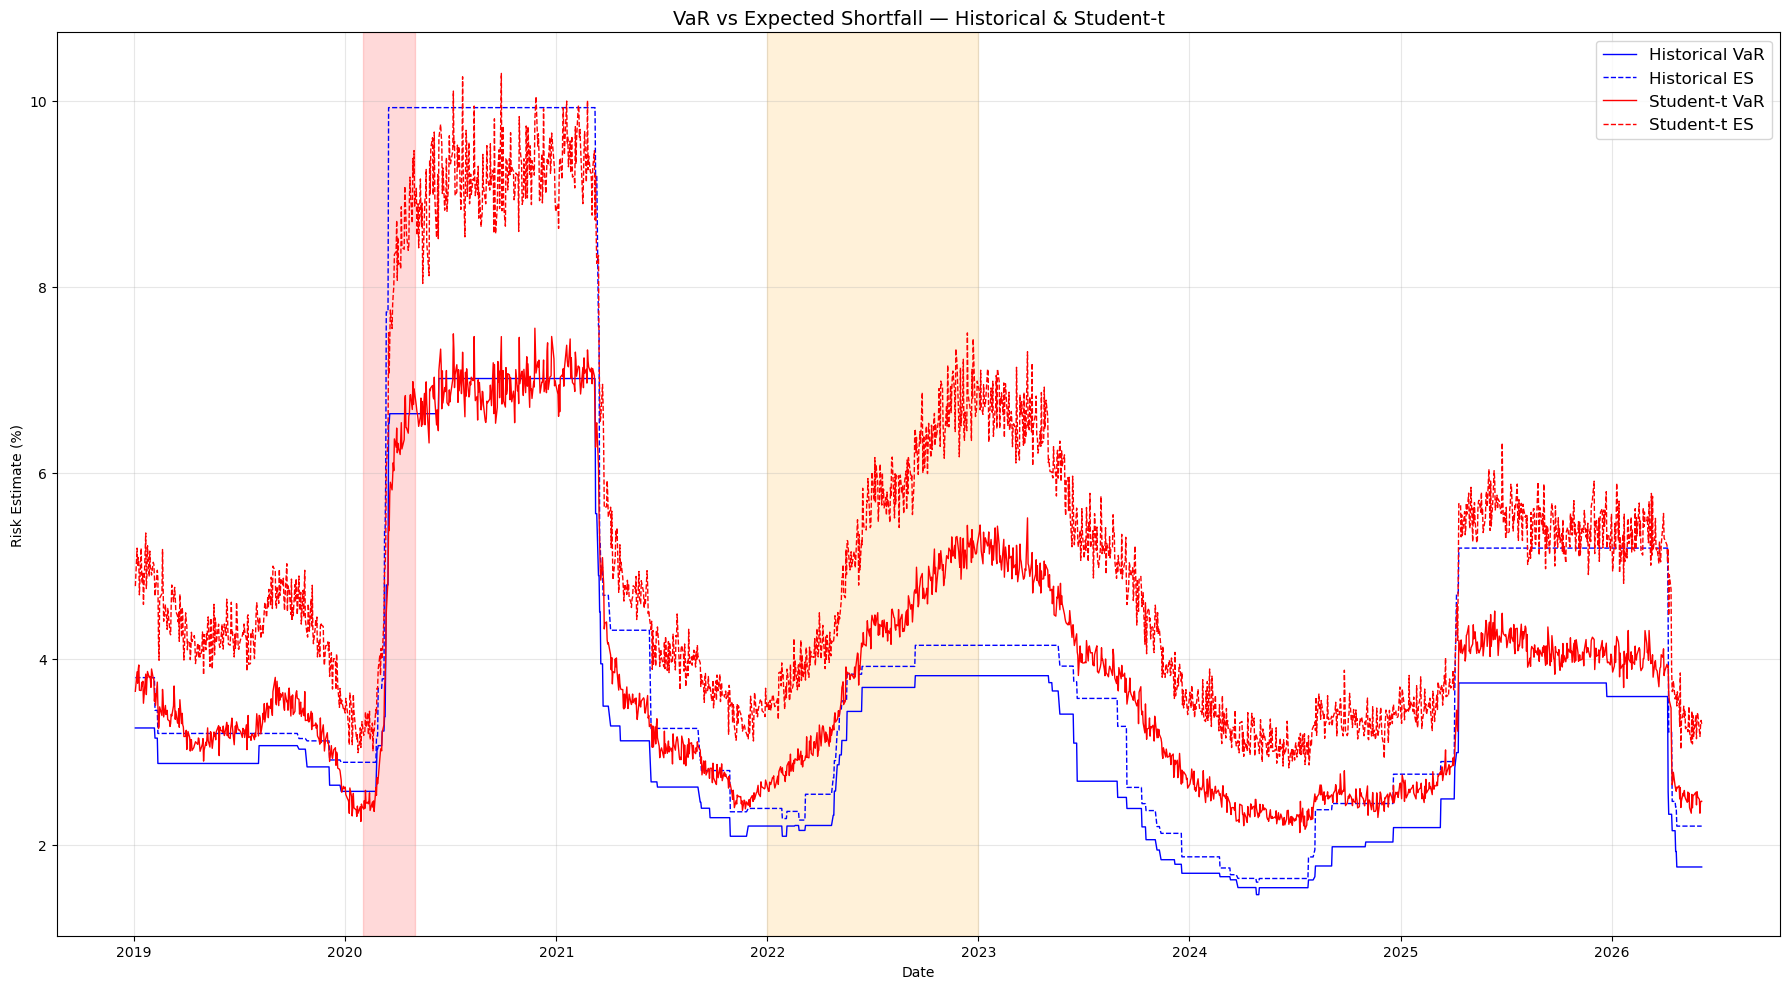

In [30]:
fig, ax = plt.subplots(figsize=(18, 10))

ax.plot(hist_var.index, hist_var.values * 100, 
        color='blue', linewidth=1, label='Historical VaR')
ax.plot(hist_es.index, hist_es.values * 100, 
        color='blue', linewidth=1, linestyle='--', label='Historical ES')

ax.plot(mc_t_var.index, mc_t_var.values * 100, 
        color='red', linewidth=1, label='Student-t VaR')
ax.plot(mc_t_es.index, mc_t_es.values * 100, 
        color='red', linewidth=1, linestyle='--', label='Student-t ES')

ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
           alpha=0.15, color='red')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.15, color='orange')

ax.set_title('VaR vs Expected Shortfall — Historical & Student-t', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Risk Estimate (%)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('var_es_gap.png', dpi=150)
plt.show()

    

In [31]:
summary= pd.DataFrame({'Method':['Historical', 'Parametric', 'MC GBM', 'MC Student-t'],
                       'Expected Breaches':[19,19,19,19], 
                       'Actual Breaches': [hits_hist.sum(), hits_param.sum(), hits_mc.sum(), hits_mc_t.sum()],
                       'Kupiec LR': [lr_hist,lr_param,lr_mc,lr_mc_t], 
                       'kupiec p-value': [pv_hist,pv_param,pv_mc,pv_mc_t],
                       'Kupiec Result': ['Fail', 'Fail', 'Fail', 'Pass'],
                       'Christoffersen LR': [lr_c_hist, lr_c_param,lr_c_mc,lr_c_mc_t],
                       'Christoffersen p- value': [pv_c_hist,pv_c_param,pv_c_mc,pv_c_mc_t],
                       'Cristoffersen Result': ['Fail', 'Fail', 'Fail', 'Fail']})
                        
                        

In [32]:
summary


,Method,Expected Breaches,Actual Breaches,Kupiec LR,kupiec p-value,Kupiec Result,Christoffersen LR,Christoffersen p- value,Cristoffersen Result
0,Historical,19,32,7.9497,0.0048,Fail,10.0151,0.0016,Fail
1,Parametric,19,50,36.4530,0.0000,Fail,6.5760,0.0103,Fail
2,MC GBM,19,50,36.4530,0.0000,Fail,6.5760,0.0103,Fail
3,MC Student-t,19,19,0.0066,0.9353,Pass,12.0521,0.0005,Fail


In [33]:
print(hist_es.describe())
print(param_es.describe())
print(mc_es.describe())
print(mc_t_es.describe())
      

count    1865.000000
mean        0.042685
std         0.024442
min         0.015973
25%         0.026158
50%         0.034448
75%         0.051890
max         0.099256
dtype: float64
count    1865.000000
mean        0.030867
std         0.011143
min         0.017579
25%         0.021658
50%         0.027856
75%         0.034776
max         0.056348
dtype: float64
count    1865.000000
mean        0.030928
std         0.011193
min         0.016935
25%         0.021649
50%         0.028171
75%         0.035046
max         0.057920
dtype: float64
count    1865.000000
mean        0.051935
std         0.018655
min         0.028253
25%         0.036842
50%         0.047740
75%         0.059102
max         0.102937
dtype: float64


In [34]:
portfolio = 1_000_000

print("=" * 55)
print(f"Portfolio Value: ${portfolio:,.0f}")
print(f"Confidence Level: 99% | Window: 252 days")
print("=" * 55)
print(f"\n{'Method':<20} {'VaR ($)':<15} {'ES ($)':<15}")
print("-" * 50)
print(f"{'Historical':<20} ${hist_var.mean()*portfolio:>10,.0f}   ${hist_es.mean()*portfolio:>10,.0f}")
print(f"{'Parametric':<20} ${param_var.mean()*portfolio:>10,.0f}   ${param_es.mean()*portfolio:>10,.0f}")
print(f"{'MC GBM':<20} ${mc_var.mean()*portfolio:>10,.0f}   ${mc_es.mean()*portfolio:>10,.0f}")
print(f"{'MC Student-t':<20} ${mc_t_var.mean()*portfolio:>10,.0f}   ${mc_t_es.mean()*portfolio:>10,.0f}")
print("=" * 55)
print(f"\nCOVID Peak Risk (March 2020):")
print("=" * 55)
covid_date = '2020-03-16'
print(f"{'Historical VaR:':<20} ${hist_var[covid_date]*portfolio:>10,.0f}")
print(f"{'Student-t VaR:':<20} ${mc_t_var[covid_date]*portfolio:>10,.0f}")
print(f"{'Historical ES:':<20} ${hist_es[covid_date]*portfolio:>10,.0f}")
print(f"{'Student-t ES:':<20} ${mc_t_es[covid_date]*portfolio:>10,.0f}")
print(f"{'Parametric VaR:':<20} ${param_var[covid_date]*portfolio:>10,.0f}")
print(f"{'Parametric ES:':<20} ${param_es[covid_date]*portfolio:>10,.0f}")
print(f"{'MC GBM VaR:':<20} ${mc_var[covid_date]*portfolio:>10,.0f}")
print(f"{'MC GBM ES:':<20} ${mc_es[covid_date]*portfolio:>10,.0f}")


Portfolio Value: $1,000,000
Confidence Level: 99% | Window: 252 days

Method               VaR ($)         ES ($)         
--------------------------------------------------
Historical           $    33,682   $    42,685
Parametric           $    26,874   $    30,867
MC GBM               $    26,931   $    30,928
MC Student-t         $    39,135   $    51,935

COVID Peak Risk (March 2020):
Historical VaR:      $    47,924
Student-t VaR:       $    48,568
Historical ES:       $    77,286
Student-t ES:        $    63,429
Parametric VaR:      $    33,724
Parametric ES:       $    38,623
MC GBM VaR:          $    34,068
MC GBM ES:           $    39,307


## 6. Conclusion

This project implements and backtests four VaR models on SPY daily returns (2018–2026)
across two stressed market regimes — the COVID-19 crash (2020) and the 2022 rate hike drawdown.

### Key Findings
- **MC Student-t (df=5)** is the only model to pass the Kupiec POF test, producing exactly
  19 breaches against an expected 19 at 99% confidence
- **Parametric and MC GBM** fail catastrophically — 50 breaches vs 19 expected — confirming
  that the normality assumption is empirically rejected for SPY returns
- **All four models fail the Christoffersen independence test** — breaches cluster during
  crisis periods, a limitation addressable only through GARCH-based extensions
- **Expected Shortfall** consistently exceeds VaR across all methods — on the COVID peak
  (March 16, 2020), Historical ES reached $77,286 vs VaR of $47,924 on a $1M portfolio,
  illustrating the tail risk VaR alone fails to capture

### Assumptions
- Log returns are stationary across the rolling window
- 252-day window captures sufficient history for risk estimation
- Student-t degrees of freedom fixed at 5 — not calibrated via MLE
- Portfolio is fully invested in SPY with no hedging or transaction costs
- Correlations and volatility are implicitly assumed stable within each rolling window

### Limitations
- **Volatility clustering** — all models treat each day equally within the window;
  GARCH weighting would improve responsiveness to regime changes
- **Static degrees of freedom** — df=5 for Student-t is assumed, not estimated;
  MLE calibration would improve tail accuracy
- **Single asset** — multi-asset extension with Cholesky-decomposed correlation
  matrix would reflect real portfolio risk more accurately
- **ES backtesting** — formal ES backtesting via Acerbi-Szekely test is beyond
  current scope; ES is reported as a supplementary tail risk metric
- **Lookback bias** — rolling window VaR is backward-looking and slow to react
  to sudden volatility spikes outside the historical sample

### Extensions
- GARCH(1,1) filtered Historical Simulation (FHS) for dynamic volatility scaling
- MLE calibration of Student-t degrees of freedom
- Multi-asset portfolio with Cholesky correlation structure
- Formal ES backtesting via Acerbi-Szekely (2014)